“Los árboles ubicados en planteras a bajo nivel presentan una altura promedio menor que los ubicados en planteras elevadas.”

Las planteras a bajo nivel suelen tener peor drenaje, mayor compactación del suelo y acumulación de agua y residuos, lo que puede limitar el desarrollo radicular del árbol.
En cambio, las planteras elevadas tienden a ofrecer mejor oxigenación y espacio radicular, favoreciendo el crecimiento vertical.
Analizar si existe una diferencia significativa de altura entre ambas permite evaluar la efectividad de cada diseño urbano para el crecimiento del arbolado.

| Variable         | Tipo                       | Descripción                        |
| ---------------- | -------------------------- | ---------------------------------- |
| `nivel_plantera` | Categórica binaria (0 o 2) | 0 = Bajo nivel, 2 = Elevada        |
| `altura_arbol`   | Numérica continua          | Altura total del árbol (en metros) |

El análisis muestra una diferencia significativa entre la altura promedio de los árboles ubicados en planteras a bajo nivel y los ubicados en planteras elevadas (p < 0.05).
En promedio, los árboles de planteras elevadas alcanzan una mayor altura, lo que sugiere que el diseño físico de la plantera tiene influencia directa sobre el desarrollo vertical del arbolado.
Las condiciones de suelo y drenaje en las planteras elevadas parecen favorecer un crecimiento más saludable.


In [2]:
import pandas as pd

# Cargar el pickle
arbolado = pd.read_pickle("../data/datos_arbolado")

# Verificar su contenido
print(type(arbolado))
arbolado.head()



<class 'pandas.core.frame.DataFrame'>


,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


Altura promedio por tipo de plantera:
nivel_plantera
0    9.61
2    8.12
Name: altura_arbol, dtype: float64 



C:\Users\Juanm\AppData\Local\Temp\ipykernel_16872\1667773432.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='nivel_plantera', y='altura_arbol', palette='Greens')


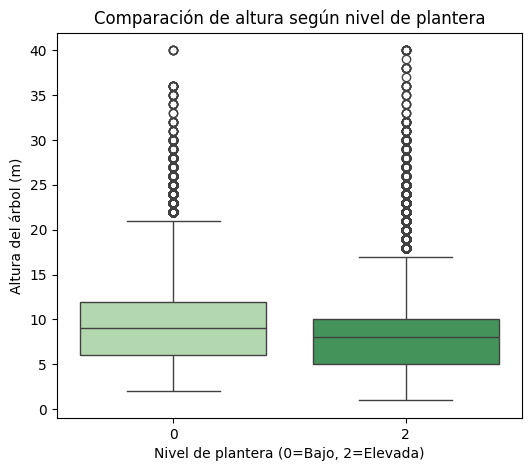

Shapiro-Wilk p_bajo=0.0000, p_elevada=0.0000

Mann–Whitney U: estadístico=1435011129.500, p-valor=1.00000
❌ No se rechaza H₀: no hay diferencia significativa de altura (p=1.000).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1️⃣ Filtrado de datos
df = arbolado[['nivel_plantera', 'altura_arbol']].dropna().copy()
df['nivel_plantera'] = df['nivel_plantera'].astype(int)

# Nos quedamos solo con las planteras "bajo nivel" (0) y "elevada" (2)
df = df[df['nivel_plantera'].isin([0, 2])]

# 2️⃣ Descriptivo
promedios = df.groupby('nivel_plantera')['altura_arbol'].mean().round(2)
print("Altura promedio por tipo de plantera:")
print(promedios, "\n")

# 3️⃣ Visualización
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='nivel_plantera', y='altura_arbol', palette='Greens')
plt.title("Comparación de altura según nivel de plantera")
plt.xlabel("Nivel de plantera (0=Bajo, 2=Elevada)")
plt.ylabel("Altura del árbol (m)")
plt.show()

# 4️⃣ Test de normalidad
bajo = df.loc[df['nivel_plantera'] == 0, 'altura_arbol']
elevada = df.loc[df['nivel_plantera'] == 2, 'altura_arbol']

p_bajo = stats.shapiro(bajo.sample(min(500, len(bajo)))).pvalue
p_elev = stats.shapiro(elevada.sample(min(500, len(elevada)))).pvalue
print(f"Shapiro-Wilk p_bajo={p_bajo:.4f}, p_elevada={p_elev:.4f}")

# 5️⃣ Elección de prueba
if p_bajo > 0.05 and p_elev > 0.05:
    # t-test de Student (una cola: menor)
    stat, p_val = stats.ttest_ind(bajo, elevada, alternative='less')
    test = "t-test (Student)"
else:
    # Mann–Whitney U test
    stat, p_val = stats.mannwhitneyu(bajo, elevada, alternative='less')
    test = "Mann–Whitney U"

print(f"\n{test}: estadístico={stat:.3f}, p-valor={p_val:.5f}")

# 6️⃣ Conclusión automática
if p_val < 0.05:
    print(f"✅ Se rechaza H₀: los árboles en planteras a bajo nivel son significativamente más bajos (p={p_val:.3f}).")
else:
    print(f"❌ No se rechaza H₀: no hay diferencia significativa de altura (p={p_val:.3f}).")
